# Experiment 2: Supervised & Unsupervised ML on Y-Chromosome Variants
## Using Fine-Grained Sub-Population Labels (26 Classes)

**Goal:**
- **Supervised:** Predict sub-population label (26 specific populations like YRI, CEU, CHB…) from per-sample genotype data using multiple classifiers.
- **Unsupervised:** Apply K-Means (k=26) to discover population clusters without labels.

**Key difference from Experiment 1:** Uses `pop` column (26 sub-populations) instead of `super_pop` (5 super-populations).

**Pipeline:**
1. Load & preprocess Y-chromosome genotype data (same QC as Experiment 1)
2. Build sample × variant feature matrix; impute missing values
3. PCA for dimensionality reduction
4. Supervised classifiers: Logistic Regression, SVM, Random Forest, Decision Tree, KNN
5. K-Means clustering (k=26) with ARI & NMI evaluation

## 0. Imports

In [24]:
import csv
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer

# Supervised classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Unsupervised
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE    = "/Users/aaditya/VS Code/1000 genome project"
VCF_CSV = f"{BASE}/Data/vcf_table.csv"
PANEL   = f"{BASE}/integrated_call_samples_v3.20130502.ALL.panel"
OUT_DIR = f"{BASE}/Output "

N_POPS = 26   # number of sub-population classes

print("Imports OK")

Imports OK


## 1. Load & Preprocess Genotype Data

In [25]:
# ── 1a. Load raw VCF table ───────────────────────────────────────────────────
with open(VCF_CSV, 'r', encoding='utf-8', errors='replace') as f:
    sample_text = ''.join([next(f) for _ in range(20)])
dialect = csv.Sniffer().sniff(sample_text, delimiters=[',', '\t', ';', '|'])
sep = dialect.delimiter

df = pd.read_csv(VCF_CSV, sep=sep, header=0, low_memory=False)
df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]

FIXED_COLS = {'#CHROM', 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'FORMAT'}
sample_cols = [c for c in df.columns if c not in FIXED_COLS]
print(f"Variants (raw): {len(df):,} | Sample columns: {len(sample_cols):,}")

Variants (raw): 62,042 | Sample columns: 1,233


In [26]:
# ── 1b. Quality filtering ────────────────────────────────────────────────────
qual = pd.to_numeric(df.get('QUAL'), errors='coerce')
filter_cols = [c for c in df.columns if c.strip().upper() == 'FILTER']

if filter_cols:
    df = df[(df[filter_cols[0]].astype(str).str.upper() == 'PASS') & (qual > 30)].copy()
else:
    df = df[qual > 30].copy()

# keep bi-allelic sites only
df = df[~df['ALT'].astype(str).str.contains(',', na=False)].copy()
print(f"Variants after QC: {len(df):,}")

Variants after QC: 61,995


In [27]:
# ── 1c. Build genotype matrix (variants × samples) ──────────────────────────
G = df[sample_cols].replace(
    {'.': pd.NA, './.': pd.NA, '0|0': 0, '1|1': 1, '0/0': 0, '1/1': 1, '0': 0, '1': 1}
)
G = G.apply(pd.to_numeric, errors='coerce')

# detect males: samples with ≥5% called sites
call_rate_per_sample = 1 - G.isna().mean()
male_mask = call_rate_per_sample > 0.05
male_samples = list(male_mask[male_mask].index)
Gm = G[male_samples]
print(f"Males detected: {len(male_samples):,}")

Males detected: 1,233


In [28]:
# ── 1d. Per-variant QC ───────────────────────────────────────────────────────
qual_clean = pd.to_numeric(df.get('QUAL'), errors='coerce').reindex(Gm.index)
var_call_rate = 1 - Gm.isna().mean(axis=1)
keep = (var_call_rate >= 0.95) & (qual_clean >= 30)
Gm_clean = Gm.loc[keep]
print(f"Variants after variant-level QC: {len(Gm_clean):,}")

# per-sample missingness filter
sample_missing = Gm_clean.isna().mean()
bad_samples = sample_missing[sample_missing > 0.1].index
Gm_clean = Gm_clean.drop(columns=bad_samples)
print(f"Samples after sample QC: {Gm_clean.shape[1]:,}")

Variants after variant-level QC: 60,789
Samples after sample QC: 1,233


## 2. Build Feature Matrix (X) and Sub-Population Labels (y)

**Key change from Exp 1:** We use the `pop` column (26 specific sub-populations) instead of `super_pop` (5 broad groups).

In [29]:
# ── 2a. Transpose → samples × variants ──────────────────────────────────────
X_raw = Gm_clean.T
print(f"Feature matrix shape: {X_raw.shape}  (samples × variants)")

Feature matrix shape: (1233, 60789)  (samples × variants)


In [30]:
# ── 2b. Load panel & extract SUB-POPULATION labels (pop column) ──────────────
panel = pd.read_csv(PANEL, sep='\t', usecols=['sample', 'pop', 'super_pop'])

# align samples
panel = panel[panel['sample'].isin(X_raw.index)].set_index('sample')
X_raw = X_raw.loc[panel.index]

y_str     = panel['pop'].to_numpy(dtype=str)
super_str = panel['super_pop'].to_numpy(dtype=str)

print(f"Sample × variant matrix: {X_raw.shape}")
print(f"\nSub-population distribution (26 classes):")
print(panel['pop'].value_counts().to_string())
print(f"\nUnique sub-populations: {panel['pop'].nunique()}")

Sample × variant matrix: (1233, 60789)

Sub-population distribution (26 classes):
pop
ITU    59
JPT    56
GIH    56
GWD    55
STU    55
PUR    54
IBS    54
ESN    53
TSI    53
CHS    52
YRI    52
CEU    49
PJL    48
ACB    47
GBR    46
KHV    46
CHB    46
CDX    44
LWK    44
CLM    43
BEB    42
MSL    42
PEL    41
FIN    38
MXL    32
ASW    26

Unique sub-populations: 26


In [31]:
# ── 2c. Impute NaN with 0 & encode labels ────────────────────────────────────
X_imputed = X_raw.fillna(0).values.astype(np.float32)

le = LabelEncoder()
y = le.fit_transform(y_str)
print(f"Classes ({len(le.classes_)}): {le.classes_}")

Classes (26): ['ACB' 'ASW' 'BEB' 'CDX' 'CEU' 'CHB' 'CHS' 'CLM' 'ESN' 'FIN' 'GBR' 'GIH'
 'GWD' 'IBS' 'ITU' 'JPT' 'KHV' 'LWK' 'MSL' 'MXL' 'PEL' 'PJL' 'PUR' 'STU'
 'TSI' 'YRI']


## 3. PCA Dimensionality Reduction

~60k variants → 50 principal components. With 26 classes we need more PCs to capture fine-grained structure.

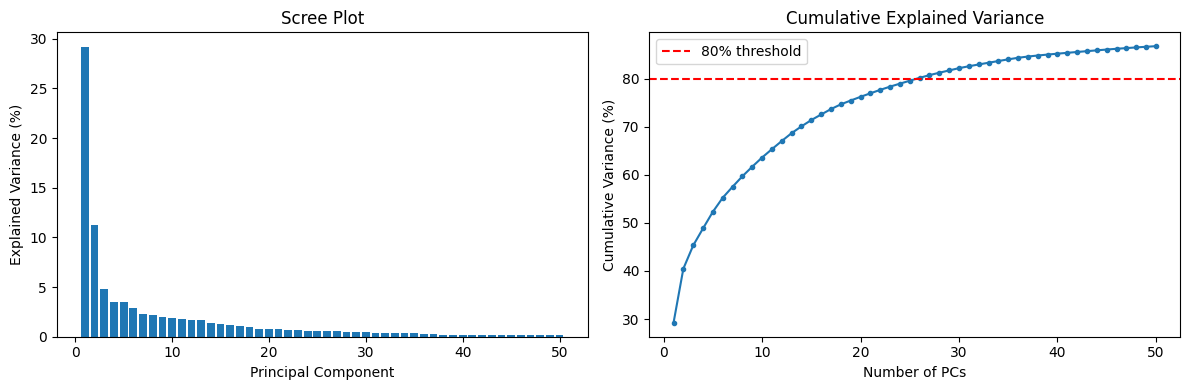

Variance explained by 50 PCs: 86.8%


In [32]:
N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_imputed)

explained = pca.explained_variance_ratio_
cum_var = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, N_COMPONENTS + 1), explained * 100)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")

axes[1].plot(range(1, N_COMPONENTS + 1), cum_var * 100, marker='o', markersize=3)
axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Variance explained by {N_COMPONENTS} PCs: {cum_var[-1]*100:.1f}%")

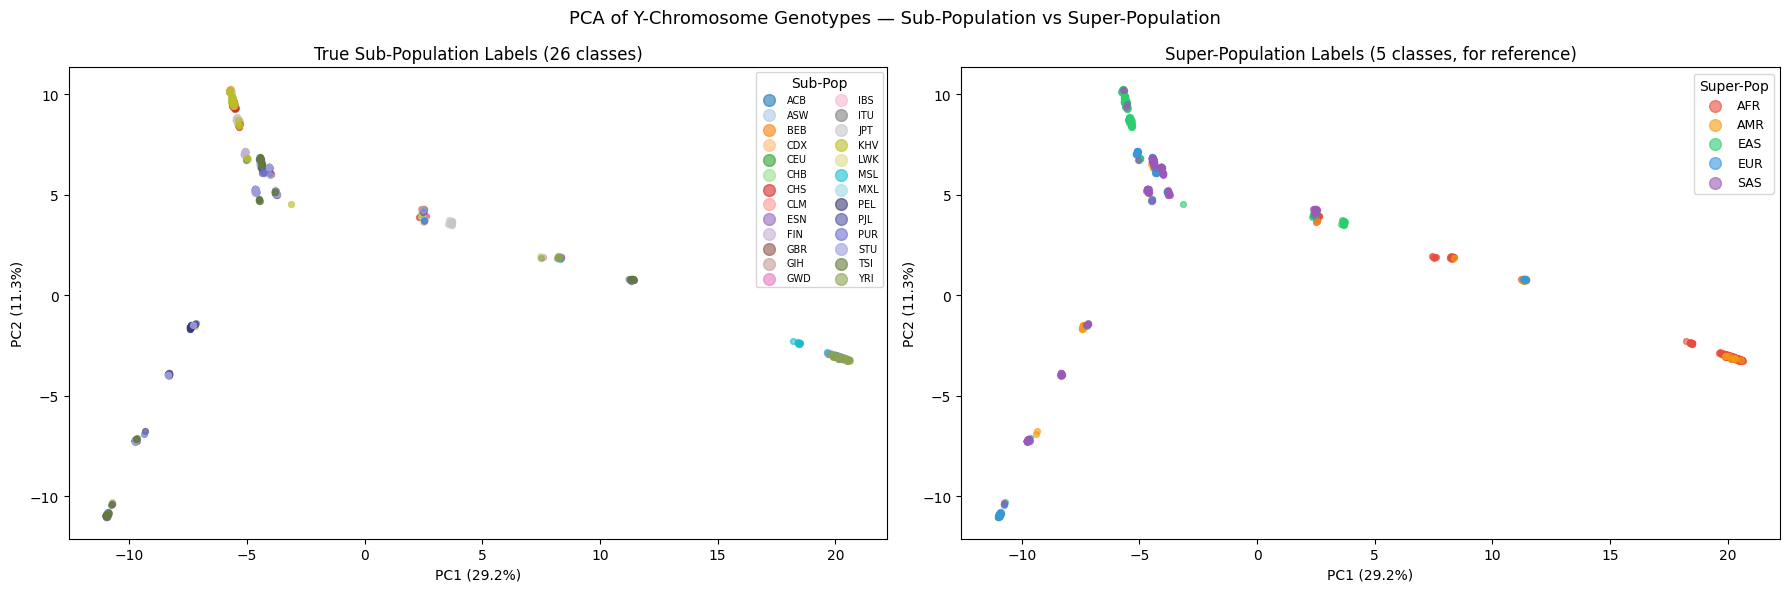

In [33]:
# ── PCA scatter: PC1 vs PC2 coloured by sub-population ──────────────────────
# Use tab20 + tab20b to get 26 distinct colours
cmap26 = [plt.cm.tab20(i) for i in range(20)] + [plt.cm.tab20b(i) for i in range(6)]
pop_color_map = {pop: cmap26[i] for i, pop in enumerate(le.classes_)}

# Also build super-pop colour map for reference
SUPER_COLORS = {'AFR': '#E74C3C', 'AMR': '#F39C12', 'EAS': '#2ECC71', 'EUR': '#3498DB', 'SAS': '#9B59B6'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: coloured by sub-population (pop)
for pop in le.classes_:
    mask = y_str == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[pop_color_map[pop]], label=pop, alpha=0.6, s=18)
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[0].set_title("True Sub-Population Labels (26 classes)")
axes[0].legend(title="Sub-Pop", markerscale=2, fontsize=7, ncol=2,
               loc='upper right', bbox_to_anchor=(1.0, 1.0))

# Right: coloured by super-population (for context)
unique_supers = np.unique(super_str)
for sp in unique_supers:
    mask = super_str == sp
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=SUPER_COLORS[sp], label=sp, alpha=0.6, s=18)
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title("Super-Population Labels (5 classes, for reference)")
axes[1].legend(title="Super-Pop", markerscale=2, fontsize=9)

plt.suptitle("PCA of Y-Chromosome Genotypes — Sub-Population vs Super-Population", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_pca_true_labels.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Supervised Classification (26 Sub-Population Classes)

**Setup:** Stratified 80/20 train-test split. PCA features (50 PCs) as input.
All models evaluated with 5-fold cross-validation on the training set.

In [34]:
X_train, X_test, y_train, y_test, y_train_str, y_test_str = train_test_split(
    X_pca, y, y_str, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

unique, counts = np.unique(y_train_str, return_counts=True)
print("Train class distribution:")
for p, c in zip(unique, counts):
    print(f"  {p}: {c}")

Train: 986 samples | Test: 247 samples
Train class distribution:
  ACB: 38
  ASW: 21
  BEB: 34
  CDX: 35
  CEU: 39
  CHB: 37
  CHS: 41
  CLM: 34
  ESN: 42
  FIN: 30
  GBR: 37
  GIH: 45
  GWD: 44
  IBS: 43
  ITU: 47
  JPT: 45
  KHV: 37
  LWK: 35
  MSL: 34
  MXL: 26
  PEL: 33
  PJL: 38
  PUR: 43
  STU: 44
  TSI: 42
  YRI: 42


In [36]:
# ── Define classifiers ───────────────────────────────────────────────────────
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, solver='lbfgs',
        C=1.0, random_state=RANDOM_STATE
    ),
    "SVM (RBF)": SVC(
        kernel='rbf', C=10, gamma='scale',
        decision_function_shape='ovo', random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=15, random_state=RANDOM_STATE
    ),
    "KNN (k=5)": KNeighborsClassifier(
        n_neighbors=5, metric='euclidean', n_jobs=-1
    ),
}

print(f"Classifiers to train: {list(classifiers.keys())}")

Classifiers to train: ['Logistic Regression', 'SVM (RBF)', 'Random Forest', 'Decision Tree', 'KNN (k=5)']


In [37]:
# ── Train, evaluate, collect results ────────────────────────────────────────
results = []
trained_models = {}

for name, clf in classifiers.items():
    print(f"\n{'─'*50}")
    print(f"Training: {name}")

    clf.fit(X_train, y_train)
    trained_models[name] = clf

    y_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    results.append({
        'Model': name,
        'Test Accuracy': round(test_acc, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
    })
    print(f"  Test Accuracy : {test_acc:.4f}")
    print(f"  CV Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


──────────────────────────────────────────────────
Training: Logistic Regression
  Test Accuracy : 0.3563
  CV Accuracy   : 0.3570 ± 0.0167
              precision    recall  f1-score   support

         ACB       0.17      0.11      0.13         9
         ASW       0.00      0.00      0.00         5
         BEB       0.00      0.00      0.00         8
         CDX       0.50      0.89      0.64         9
         CEU       0.00      0.00      0.00        10
         CHB       0.45      0.56      0.50         9
         CHS       0.75      0.55      0.63        11
         CLM       0.00      0.00      0.00         9
         ESN       1.00      0.55      0.71        11
         FIN       1.00      0.38      0.55         8
         GBR       0.00      0.00      0.00         9
         GIH       0.50      0.18      0.27        11
         GWD       0.69      0.82      0.75        11
         IBS       0.18      0.73      0.29        11
         ITU       0.25      0.50      0.33     

In [38]:
# ── Summary comparison table ─────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n=== Model Comparison (26 Sub-Populations) ===")
print(results_df.to_string(index=False))


=== Model Comparison (26 Sub-Populations) ===
              Model  Test Accuracy  CV Mean  CV Std
          SVM (RBF)         0.3846   0.3550  0.0103
      Random Forest         0.3846   0.3713  0.0374
          KNN (k=5)         0.3765   0.3530  0.0124
Logistic Regression         0.3563   0.3570  0.0167
      Decision Tree         0.3320   0.3155  0.0214


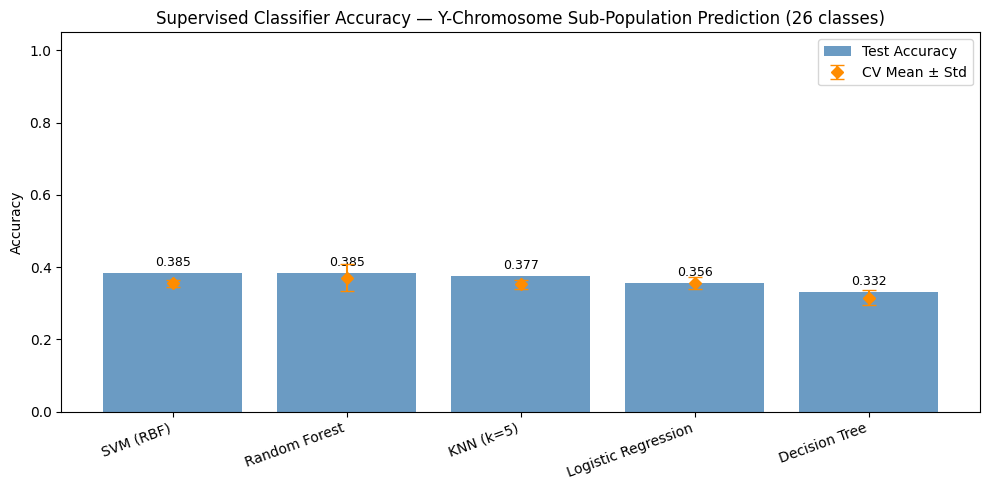

In [39]:
# ── Bar chart: model accuracy comparison ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
bars = ax.bar(x, results_df['Test Accuracy'], color='steelblue', alpha=0.8, label='Test Accuracy')
ax.errorbar(x, results_df['CV Mean'], yerr=results_df['CV Std'],
            fmt='D', color='darkorange', capsize=5, label='CV Mean ± Std', zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Supervised Classifier Accuracy — Y-Chromosome Sub-Population Prediction (26 classes)')
ax.set_ylim(0, 1.05)
ax.legend()
for bar, val in zip(bars, results_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_classifier_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

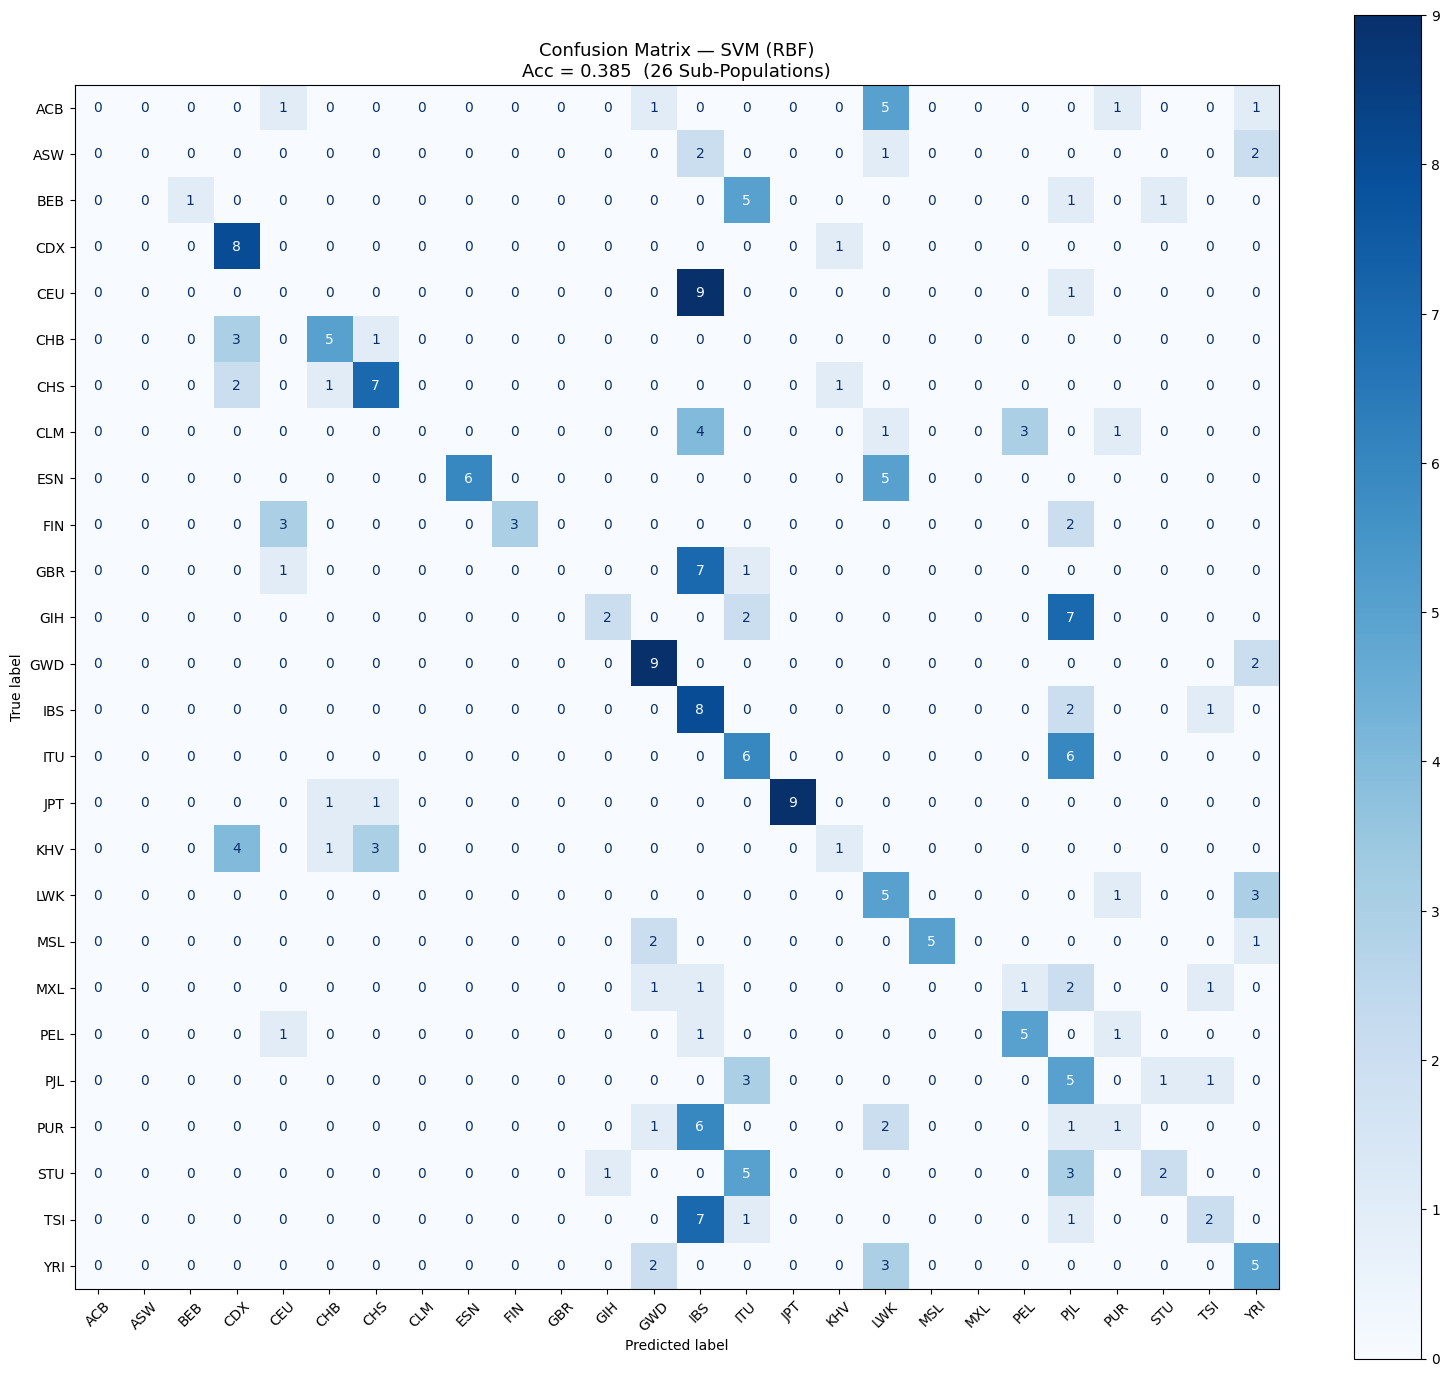


Best model: SVM (RBF)
              precision    recall  f1-score   support

         ACB       0.00      0.00      0.00         9
         ASW       0.00      0.00      0.00         5
         BEB       1.00      0.12      0.22         8
         CDX       0.47      0.89      0.62         9
         CEU       0.00      0.00      0.00        10
         CHB       0.62      0.56      0.59         9
         CHS       0.58      0.64      0.61        11
         CLM       0.00      0.00      0.00         9
         ESN       1.00      0.55      0.71        11
         FIN       1.00      0.38      0.55         8
         GBR       0.00      0.00      0.00         9
         GIH       0.67      0.18      0.29        11
         GWD       0.56      0.82      0.67        11
         IBS       0.18      0.73      0.29        11
         ITU       0.26      0.50      0.34        12
         JPT       1.00      0.82      0.90        11
         KHV       0.33      0.11      0.17         9
    

In [40]:
# ── Confusion matrices (best model only — 26×26 is large) ────────────────────
best_name = results_df.iloc[0]['Model']
best_clf  = trained_models[best_name]
y_pred_best = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
acc = accuracy_score(y_test, y_pred_best)
ax.set_title(f"Confusion Matrix — {best_name}\nAcc = {acc:.3f}  (26 Sub-Populations)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_confusion_matrix_best.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest model: {best_name}")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

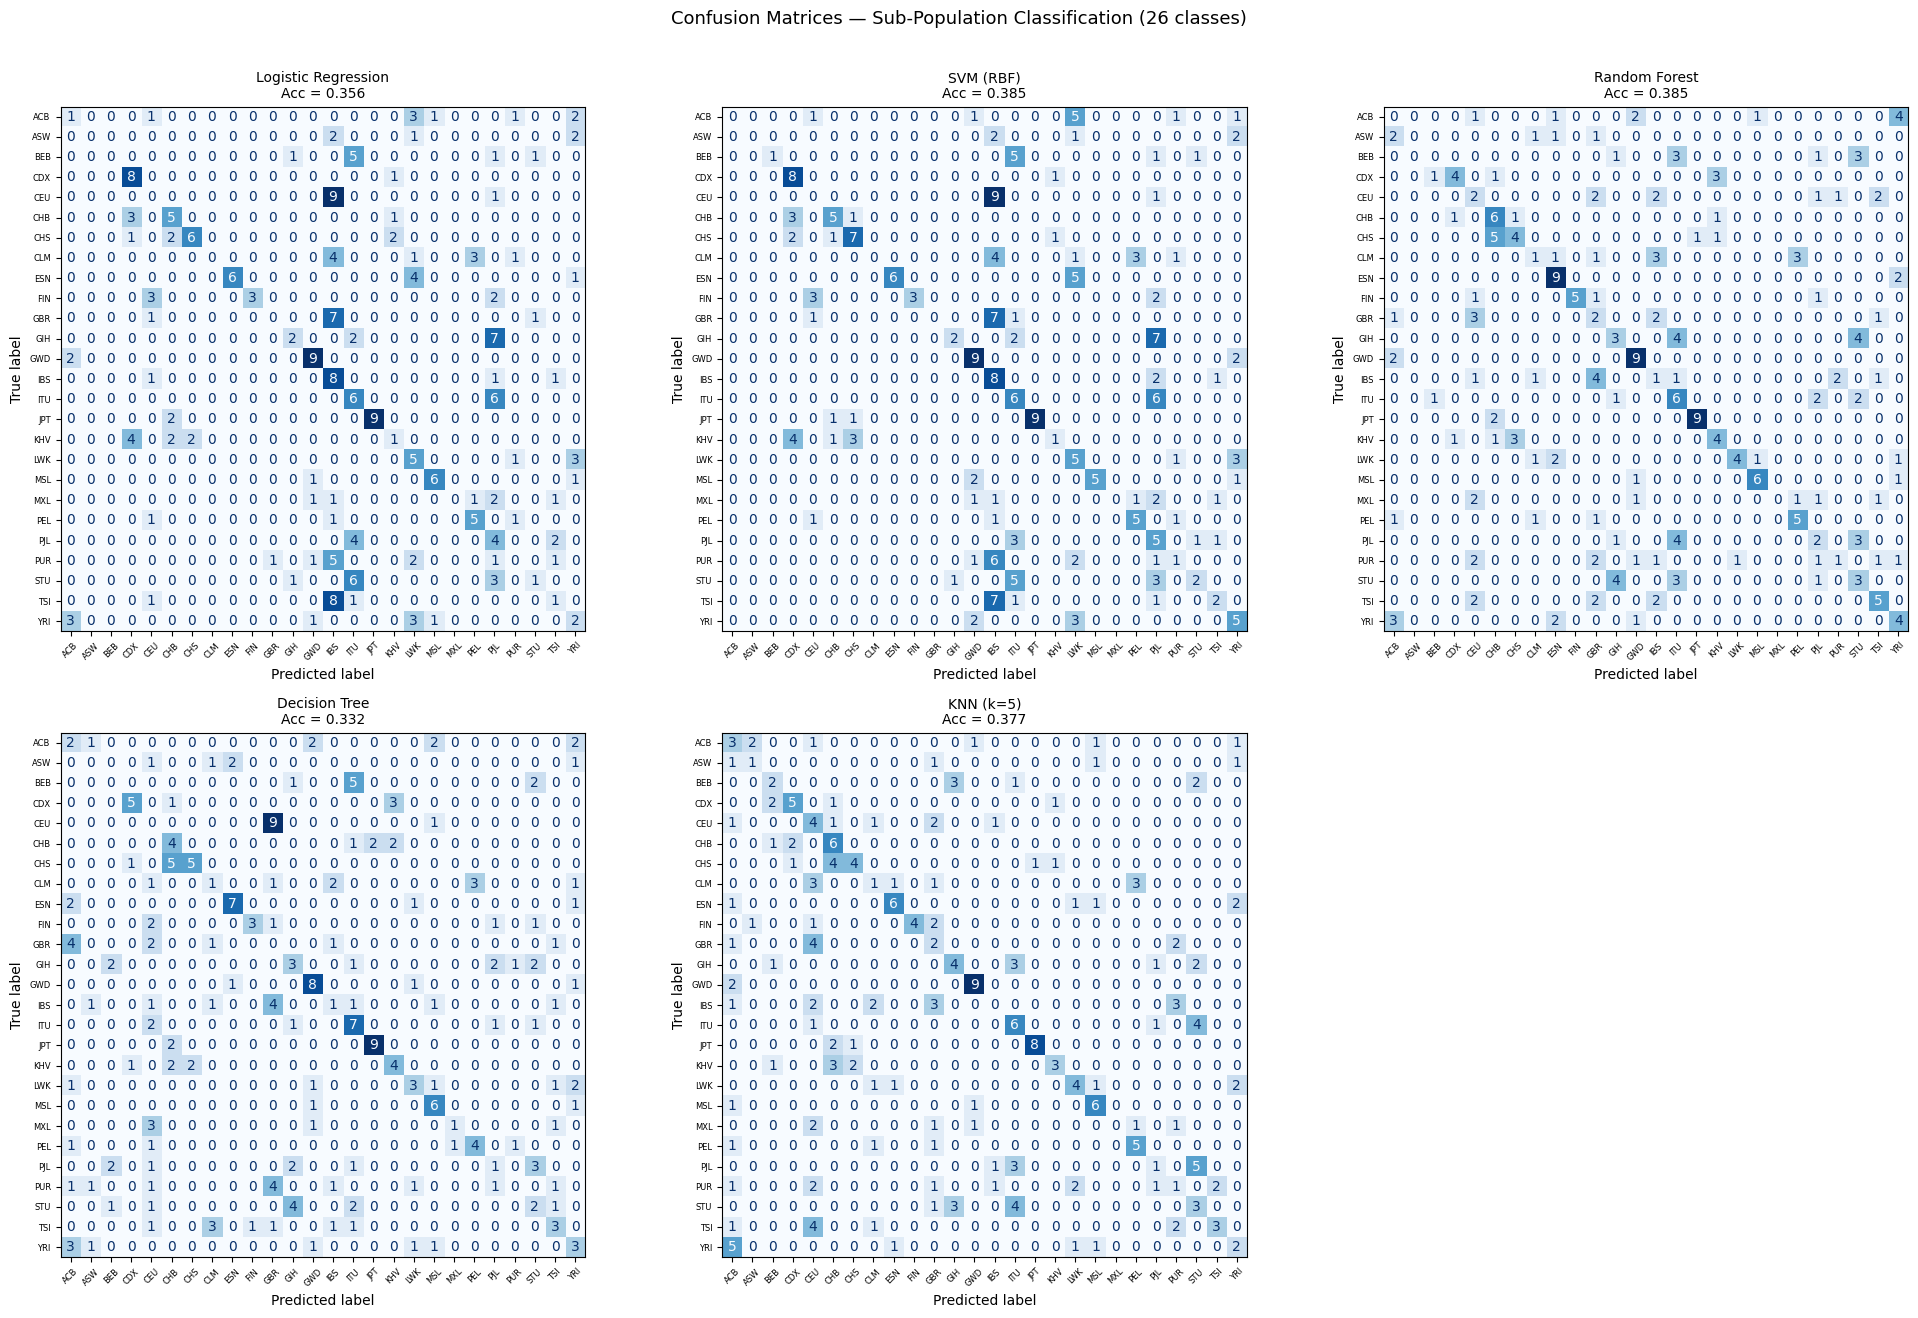

In [41]:
# ── Confusion matrices: all classifiers (small multiples) ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for idx, (name, clf) in enumerate(trained_models.items()):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues', xticks_rotation=45)
    axes[idx].set_title(f"{name}\nAcc = {accuracy_score(y_test, y_pred):.3f}", fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=6)

axes[-1].set_visible(False)
plt.suptitle("Confusion Matrices — Sub-Population Classification (26 classes)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_confusion_matrices_all.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Unsupervised: K-Means Clustering (k=26)

k=26 matches the 26 sub-population classes. We compare discovered clusters to true labels using **Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)**.

In [42]:
# ── Fit K-Means (k=26) on full PCA-reduced data ──────────────────────────────
kmeans = KMeans(n_clusters=N_POPS, n_init=20, max_iter=500, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_pca)

ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)

print(f"K-Means (k={N_POPS}) Results")
print(f"  Adjusted Rand Index (ARI) : {ari:.4f}  (1.0 = perfect, 0 = random)")
print(f"  Normalized Mutual Info    : {nmi:.4f}  (1.0 = perfect, 0 = no shared info)")
print(f"  Inertia                   : {kmeans.inertia_:.2f}")

K-Means (k=26) Results
  Adjusted Rand Index (ARI) : 0.1780  (1.0 = perfect, 0 = random)
  Normalized Mutual Info    : 0.4910  (1.0 = perfect, 0 = no shared info)
  Inertia                   : 47358.37


In [43]:
# ── Map each cluster → majority sub-population (for accuracy estimate) ────────
composition_df = pd.DataFrame({'cluster': cluster_labels, 'true_pop': y_str})
cluster_to_pop = composition_df.groupby('cluster')['true_pop'].agg(lambda x: x.mode()[0])
predicted_pop  = composition_df['cluster'].map(cluster_to_pop)

cluster_acc = accuracy_score(y_str, predicted_pop)
print(f"Clustering Accuracy (majority-vote mapping): {cluster_acc:.4f}")

comp_table = composition_df.groupby(['cluster', 'true_pop']).size().unstack(fill_value=0)
comp_pct   = comp_table.div(comp_table.sum(axis=1), axis=0).round(3)

print("\nCluster composition (counts):")
print(comp_table)
print("\nCluster composition (proportions):")
print(comp_pct)

Clustering Accuracy (majority-vote mapping): 0.3179

Cluster composition (counts):
true_pop  ACB  ASW  BEB  CDX  CEU  CHB  CHS  CLM  ESN  FIN  ...  KHV  LWK  \
cluster                                                     ...             
0           0    0    0    8    0    5    2    0    0    0  ...    2    0   
1          29   16    0    0    0    0    0    3   53    0  ...    0   36   
2           7    5    0    0   30    1    0   24    0    1  ...    0    0   
3           3    1    0    0    8    0    0    0    0    9  ...    0    0   
4           0    0    2    0    2    0    0    7    0    1  ...    1    0   
5           0    0    0    0    0    0    0    0    0    0  ...    0    0   
6           0    0    2    0    0    0    0    0    0    0  ...    0    0   
7           0    0    9    0    2    0    0    0    0    3  ...    0    0   
8           0    0    0    2    0    8   30    0    0    0  ...   13    0   
9           2    1    0    0    0    0    0    5    0    0  ...    0  

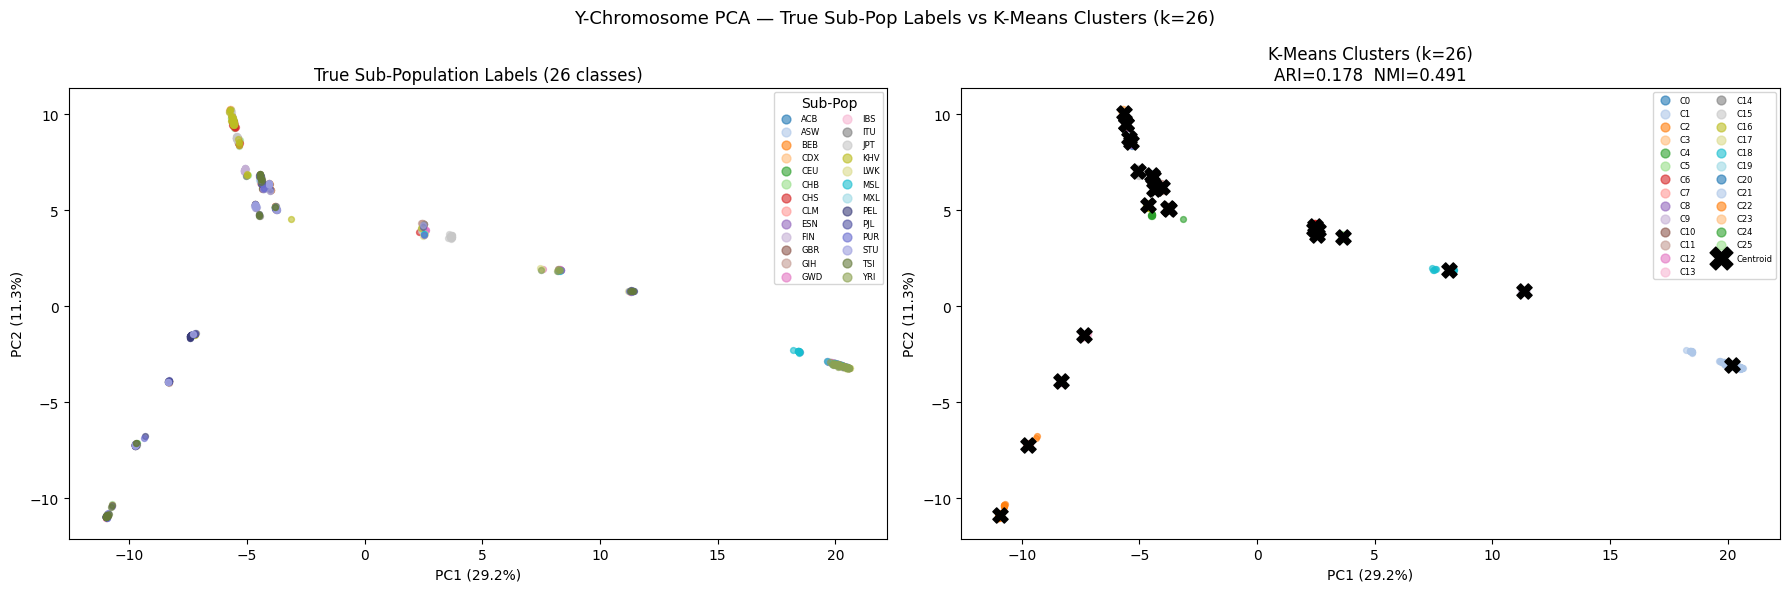

In [44]:
# ── Side-by-side PCA scatter: True sub-pop labels vs K-Means clusters ─────────
cluster_colors = [plt.cm.tab20(i % 20) for i in range(N_POPS)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: true sub-pop labels
for pop in le.classes_:
    mask = y_str == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[pop_color_map[pop]], label=pop, alpha=0.6, s=18)
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[0].set_title("True Sub-Population Labels (26 classes)")
axes[0].legend(title="Sub-Pop", markerscale=1.5, fontsize=6, ncol=2)

# Right: K-Means clusters
for k in range(N_POPS):
    mask = cluster_labels == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=cluster_colors[k], label=f"C{k}", alpha=0.6, s=18)
centroids_2d = kmeans.cluster_centers_[:, :2]
axes[1].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                c='black', marker='X', s=120, zorder=10, label='Centroid')
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title(f"K-Means Clusters (k={N_POPS})\nARI={ari:.3f}  NMI={nmi:.3f}")
axes[1].legend(markerscale=1.5, fontsize=6, ncol=2)

plt.suptitle("Y-Chromosome PCA — True Sub-Pop Labels vs K-Means Clusters (k=26)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_kmeans_vs_true.png", dpi=150, bbox_inches='tight')
plt.show()

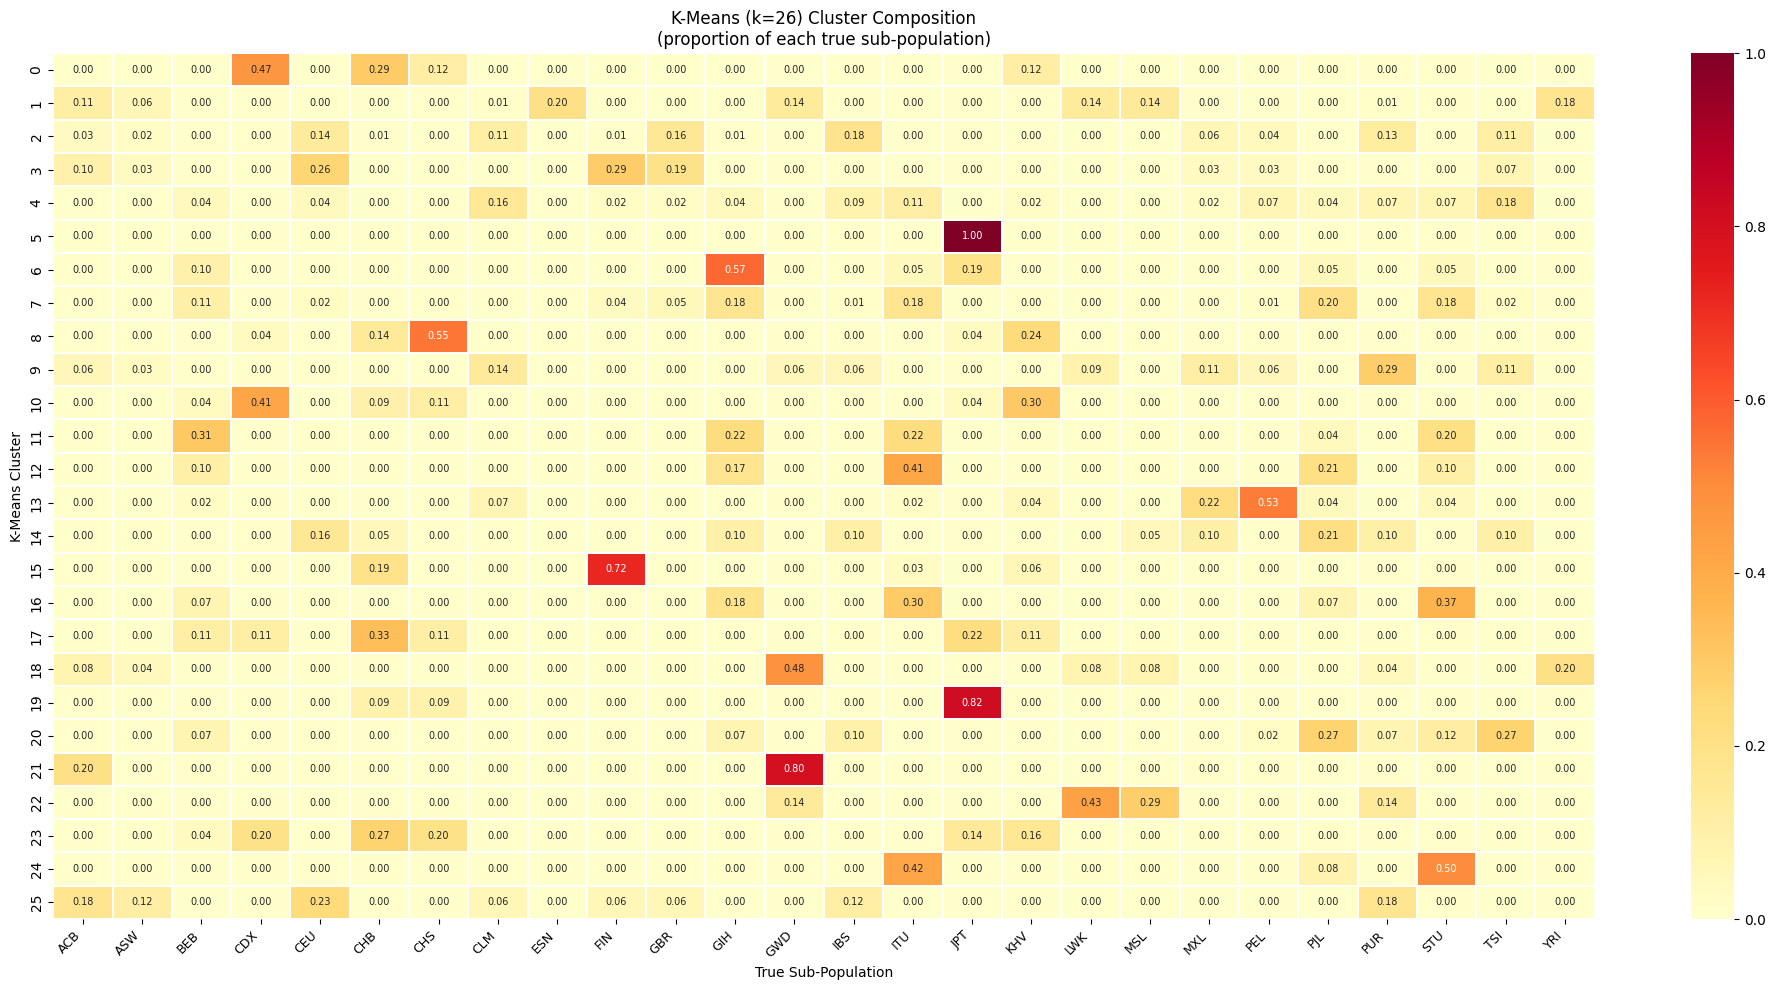

In [45]:
# ── Heatmap: cluster composition proportions ──────────────────────────────────
plt.figure(figsize=(20, 10))
sns.heatmap(comp_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.3, vmin=0, vmax=1, annot_kws={'size': 7})
plt.title(f"K-Means (k={N_POPS}) Cluster Composition\n(proportion of each true sub-population)")
plt.xlabel("True Sub-Population")
plt.ylabel("K-Means Cluster")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_kmeans_composition_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


Cluster size distribution:
0      17
1     262
2     215
3      31
4      45
5      20
6      21
7      84
8      55
9      35
10     53
11     49
12     29
13     45
14     19
15     32
16     27
17      9
18     25
19     22
20     41
21      5
22      7
23     56
24     12
25     17


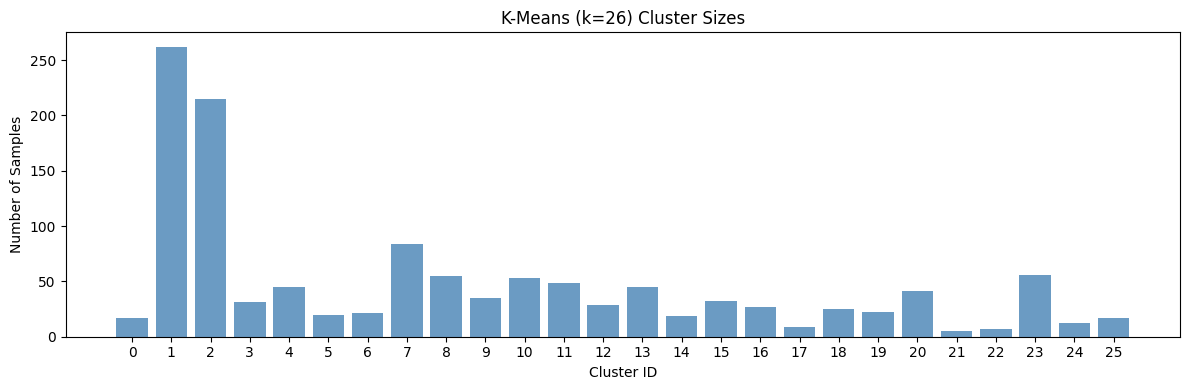

In [46]:
# ── Cluster distribution ──────────────────────────────────────────────────────
print("\nCluster size distribution:")
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_sizes.to_string())

plt.figure(figsize=(12, 4))
plt.bar(cluster_sizes.index, cluster_sizes.values, color='steelblue', alpha=0.8)
plt.xlabel("Cluster ID")
plt.ylabel("Number of Samples")
plt.title(f"K-Means (k={N_POPS}) Cluster Sizes")
plt.xticks(range(N_POPS))
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_kmeans_cluster_sizes.png", dpi=150, bbox_inches='tight')
plt.show()

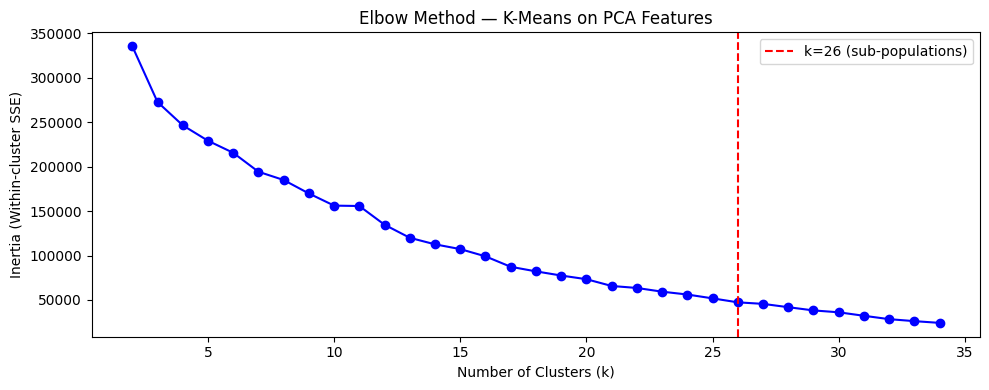

In [47]:
# ── Elbow method: validate k=26 ───────────────────────────────────────────────
inertias = []
k_range = range(2, 35)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(list(k_range), inertias, 'bo-', markersize=6)
plt.axvline(x=N_POPS, color='red', linestyle='--', label=f'k={N_POPS} (sub-populations)')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method — K-Means on PCA Features")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp2_kmeans_elbow.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Final Summary

In [48]:
print("=" * 60)
print("EXPERIMENT 2 — FINAL SUMMARY")
print("=" * 60)
print(f"\nDataset: {X_pca.shape[0]} male samples | {X_imputed.shape[1]:,} variants | 50 PCs")
print(f"Target : {N_POPS} sub-populations (pop column) — {list(le.classes_)}")

print("\n── SUPERVISED (Test Accuracy) ──")
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} {row['Test Accuracy']:.4f}  "
          f"(CV: {row['CV Mean']:.4f} ± {row['CV Std']:.4f})")

best = results_df.iloc[0]
print(f"\n  Best model: {best['Model']} (Test Acc = {best['Test Accuracy']:.4f})")

print(f"\n── UNSUPERVISED (K-Means, k={N_POPS}) ──")
print(f"  ARI                     : {ari:.4f}")
print(f"  NMI                     : {nmi:.4f}")
print(f"  Clustering Accuracy     : {cluster_acc:.4f}  (majority-vote mapping)")

print("\nAll plots saved to Output/ directory.")
print("=" * 60)

EXPERIMENT 2 — FINAL SUMMARY

Dataset: 1233 male samples | 60,789 variants | 50 PCs
Target : 26 sub-populations (pop column) — [np.str_('ACB'), np.str_('ASW'), np.str_('BEB'), np.str_('CDX'), np.str_('CEU'), np.str_('CHB'), np.str_('CHS'), np.str_('CLM'), np.str_('ESN'), np.str_('FIN'), np.str_('GBR'), np.str_('GIH'), np.str_('GWD'), np.str_('IBS'), np.str_('ITU'), np.str_('JPT'), np.str_('KHV'), np.str_('LWK'), np.str_('MSL'), np.str_('MXL'), np.str_('PEL'), np.str_('PJL'), np.str_('PUR'), np.str_('STU'), np.str_('TSI'), np.str_('YRI')]

── SUPERVISED (Test Accuracy) ──
  SVM (RBF)              0.3846  (CV: 0.3550 ± 0.0103)
  Random Forest          0.3846  (CV: 0.3713 ± 0.0374)
  KNN (k=5)              0.3765  (CV: 0.3530 ± 0.0124)
  Logistic Regression    0.3563  (CV: 0.3570 ± 0.0167)
  Decision Tree          0.3320  (CV: 0.3155 ± 0.0214)

  Best model: SVM (RBF) (Test Acc = 0.3846)

── UNSUPERVISED (K-Means, k=26) ──
  ARI                     : 0.1780
  NMI                     : 0.4